# Support Vector Machine (SVM) Classifier

<br>
<img src="./img/5_SVM_margin.png" width="400px">

<span style="font-size: 70%">Source: [Wikipedia](https://en.wikipedia.org/wiki/Support_vector_machine)</span>
<br><br>

`SVM` maps training examples to points in space so as to __maximise__ the width of __the gap between the two categories__. 

New examples are then mapped into that same space and predicted to belong to a category based on which side of the gap they fall.

<br>

### Some theory

Given a training set: &nbsp; $ (X, y) $

we can define a hyperplane:

$ w^T x - b = 0 $ &nbsp;&nbsp; with $ w $ ... normal vector of the hyperplane &nbsp;&nbsp;  and $ \frac{b}{\left\| w \right\|} $ ... offset of the hyperplane from the origin

##### Hard margin

If the training data is linearly seperable, we can find two additional hyperplanes that clearly select decision boundaries and maximize the distance between these two hyperplanes.

$ w^T x - b \ge 1 $ &nbsp; for class 0 (blue dots in the figure above)

$ w^T x - b \le -1 $ &nbsp; for class 1 (green dots in the figure above)

The distance between these two hyperplanes is $ \frac{2}{\left\| w \right\|} $.  
To maximize the distance, we need to minimize $ \left\| w \right\| $.

<br>
This problem is solved using the signum function.

<img src="./img/5_Signum_function.png" width="300px"><br><br>

##### Soft margin

If data is not linearly seperable (some points fall into the margin or even in the area of the other class), we might use:

$ \max \left( 0, 1 - y_i \left( w^T x_i - b \right) \right) $ &nbsp; ... Hinge loss

<img src="./img/5_Hinge_loss.png" width="300px"><br><br>

The goal is to optimize (minimize)

$ \lambda \left\| w \right\|^2 + \left[ \frac{1}{n} \sum_{i=1}^n \max \left( 0, 1 - y_i \left( w^T x_i - b \right) \right) \right] $ &nbsp;&nbsp; with $ \lambda \gt 0 $ ... tradeoff between margin size and classification errors.

##### Nonlinear classification

Nonlinear data can be classified using [`kernel tricks`](https://en.wikipedia.org/wiki/Kernel_method#Mathematics:_the_kernel_trick) - projections of data into higher dimensional spaces for separation.

<img src="./img/5_Kernel_trick_idea.png" width="600px">

<span style="font-size: 70%">The data shown cannot be separated by drawing a straight line (<b>left</b>). Linear classification is not possible in this case.<br>By projecting the data into 3D space, data becomes separable along a flat hyperplane (<b>right</b>).<br>Source: [Wikipedia](https://en.wikipedia.org/wiki/Kernel_method#Mathematics:_the_kernel_trick)</span><br><br>

SVM with kernel &nbsp; $ \phi \left( a, b \right) = \left( a, b, a^2 + b^2 \right) $

$ \to k \left( x, y \right) = x \cdot y + \left\| x \right\|^2 \left\| y \right\|^2 $

The training points are mapped to a 3-dimensional space where a separating hyperplane can be easily found.

<br>

__Popular kernels:__

- Polynomial: &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $ k \left( x, y \right) = \left( x_i, y_j \right)^d $ &nbsp;&nbsp; with $ d = 1 $ ... linear kernel
- Gaussian RBF (radial basis function): &nbsp; $ k \left( x, y \right) = \exp \left( - \gamma \left\| x_i - x_j \right\|^2 \right) $
- Sigmoid: &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $ k \left( x, y \right) = \tanh \left( \kappa x_i \cdot x_j + c \right) $

<br>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Read about <a href="https://en.wikipedia.org/wiki/Support_vector_machine">Support Vector Machine</a> in Wikipedia,</li>
<li><a href="https://scikit-learn.org/stable/modules/svm.html">Support Vector Machines (SVM)</a> in Scikit learn</li>
<li>12. Support Vector Machines (SVM) - theory and practice in <br>"<a href="./material/The Complete Hands-On Machine Learning Crash Course, M.Peixeiro (2019).pdf">The Complete Hands-On Machine Learning Crash Course</a>" p44 ff</li>
</ul>
</td>
</tr>
</table>

### IRIS Classification using SVM

Let's apply our knowledge.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# prepare the data
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [3]:
# model generation

svm = SVC()
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


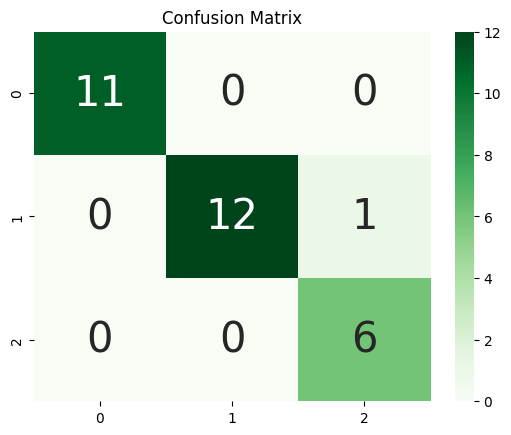

Accuracy:
 Train: 97.50 %
 Test:  96.67 %


In [4]:
# test model quality

y_pred=svm.predict(X_test)

# generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# visualize the confusion matrix
ax = plt.axes()
sns.heatmap(cm, annot=True, annot_kws={"size": 30}, cmap="Greens", ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

print('Accuracy:')
print(f' Train: {accuracy_score(y_train, svm.predict(X_train))*100:.2f} %')
print(f' Test:  {accuracy_score(y_test, y_pred)*100:.2f} %')


##### Decision boundaries

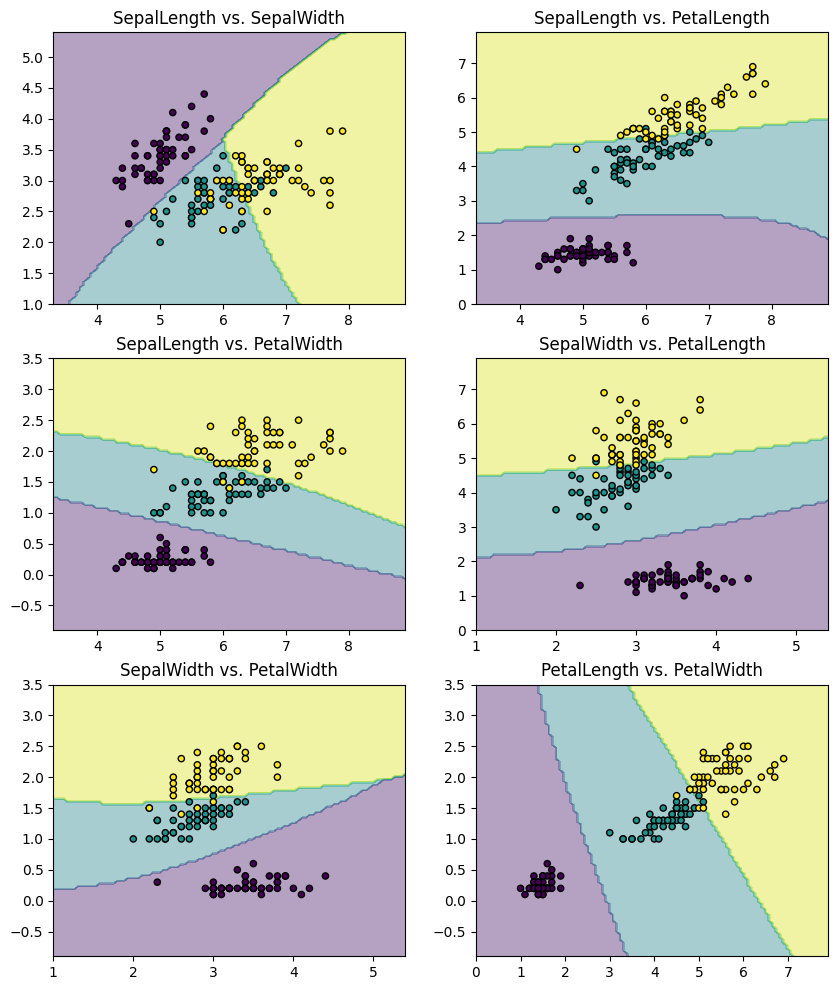

In [5]:
# only needed for display of decission boundaries
from itertools import product
from sklearn.inspection import DecisionBoundaryDisplay

# create a dataframe for statistic evaluation
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
df = pd.DataFrame(iris.data, columns=feature_columns)
df['Species'] = pd.Series(iris.target_names[iris.target])

# all combinations to compare
X_cols_combo = [["SepalLengthCm", "SepalWidthCm"], ["SepalLengthCm", "PetalLengthCm"],
                ["SepalLengthCm", "PetalWidthCm"], ["SepalWidthCm", "PetalLengthCm"],
                ["SepalWidthCm", "PetalWidthCm"], ["PetalLengthCm", "PetalWidthCm"]]

# comparing datasets
X1 = df[X_cols_combo[0]].to_numpy()
X2 = df[X_cols_combo[1]].to_numpy()
X3 = df[X_cols_combo[2]].to_numpy()
X4 = df[X_cols_combo[3]].to_numpy()
X5 = df[X_cols_combo[4]].to_numpy()
X6 = df[X_cols_combo[5]].to_numpy()
y = iris.target

# generating a forrest of classifiers
clf_1 = SVC()
clf_2 = SVC()
clf_3 = SVC()
clf_4 = SVC()
clf_5 = SVC()
clf_6 = SVC()

# make things iterable
clf_all = [clf_1, clf_2, clf_3, clf_4, clf_5, clf_6]
X_sets = [X1, X2, X3, X4, X5, X6]

# helper to generate the image position
img_pos = [pos_t for pos_t in product([0, 1, 2], [0, 1])]

f, ax = plt.subplots(3, 2, figsize=(10, 12))

for i, classifier in enumerate(clf_all):
    classifier.fit(X_sets[i], y)
    DecisionBoundaryDisplay.from_estimator(
        classifier, X_sets[i], alpha=0.4, ax=ax[img_pos[i][0], img_pos[i][1]], response_method="predict")
    ax[img_pos[i][0], img_pos[i][1]].scatter(X_sets[i][:, 0], X_sets[i][:, 1], c=y, s=20, edgecolor="k")
    ax[img_pos[i][0], img_pos[i][1]].set_title(f"{X_cols_combo[i][0][:-2]} vs. {X_cols_combo[i][1][:-2]}")


##### Comparing kernels

It is interesting to see how different kernels separate and classify this data.

We use Petal length vs. Petal Width in this example but you can experiment with different combinations.

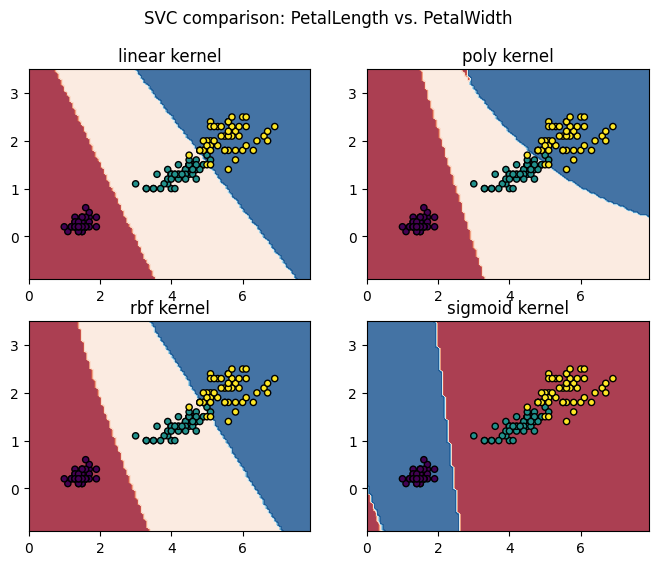

In [6]:
# only needed for display of decission boundaries

feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
df = pd.DataFrame(iris.data, columns=feature_columns)
df['Species'] = pd.Series(iris.target_names[iris.target])

# all combinations to compare
X_cols_combo = [["SepalLengthCm", "SepalWidthCm"], ["SepalLengthCm", "PetalLengthCm"],
                ["SepalLengthCm", "PetalWidthCm"], ["SepalWidthCm", "PetalLengthCm"],
                ["SepalWidthCm", "PetalWidthCm"], ["PetalLengthCm", "PetalWidthCm"]]

kernels = ["linear", "poly", "rbf", "sigmoid"]

# comparing datasets
X = df[X_cols_combo[5]].to_numpy()                              # change the X_cols_combo index to experiment with different combinations
y = iris.target

# generating a forrest of classifiers
clf_1 = SVC(kernel=kernels[0])
clf_2 = SVC(kernel=kernels[1])
clf_3 = SVC(kernel=kernels[2])
clf_4 = SVC(kernel=kernels[3], gamma="auto")

# make things iterable
clf_all = [clf_1, clf_2, clf_3, clf_4]

# helper to generate the image position
img_pos = [pos_t for pos_t in product([0, 1], [0, 1])]

f, ax = plt.subplots(2, 2, figsize=(8, 6))

for i, classifier in enumerate(clf_all):
    classifier.fit(X6, y)
    DecisionBoundaryDisplay.from_estimator(
        classifier, X, alpha=0.8, ax=ax[img_pos[i][0], img_pos[i][1]], response_method="predict", cmap=plt.cm.RdBu)
    ax[img_pos[i][0], img_pos[i][1]].scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor="k")
    ax[img_pos[i][0], img_pos[i][1]].set_title(f"{kernels[i]} kernel")

plt.suptitle("SVC comparison: PetalLength vs. PetalWidth")
plt.show()


It is interesting to note that the `sigmoid` (or $tanh$) kernel does not separate `Iris virginica` and `Iris versicolor` at all.

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task: Discuss</h5>
<ul>
    <li>Why does the sigmoid kernel not differentiate all classes (possible reasons)?</li>
    <li>How could we correctly classify all three classes using the sigmoid kernel?</li>
</ul>
</td>
</tr>
</table>

<span style="font-size: 128px">&#9749;</span> Coffee break!